# Part 1: Requirements

In [1]:
import sys
sys.path.append(r".\ChainEnsembles-main\src")

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('API_KEY')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN')

In [3]:
import chain_sim
from chain_sim import get_permutations, chain_dataframes, backward_pass

import data_utils

import hf_link
from hf_link import HuggingFaceLink, MODELS_TESTED

import llm_chain
from llm_chain import LLMChain

# import llm_label.py
# THIS MODULE HAS BEEN ADJUSTED FOR NOTEBOOK USE. 
#    - NO COMMAND LINE FUNCTIONALITY
#    - PROMPT MODIFICATION ADDED FOR FEW-SHOT FUNCTIONALITY

import openai_link
from openai_link import OpenAILink

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import accuracy_score

from transformers import T5ForConditionalGeneration, AutoModelForCausalLM, BitsAndBytesConfig

# Part 2: Chain Ensemble

In [4]:
data_df = pd.DataFrame({"prompts": ["Im against something", "Im for something"], 
                        "Stance": ["against", "for"]})
labels = ["for", "against", "neutral"]
label_metric = data_df.columns[1] # stance in this case

In [5]:
gpt4_mini_link = OpenAILink(model_name="gpt-4o-mini", labels = labels)

phi_link = HuggingFaceLink(model_name="microsoft/Phi-3-medium-128k-instruct",
                          model_class=AutoModelForCausalLM,
                          labels=labels,
                          cuda_support=False)

In [6]:
links = [gpt4_mini_link]
llm_chain = LLMChain(links)

# Define the output directory path
output_dir = "./chain_out"

# Create the directory if it doesn't already exist
os.makedirs(output_dir, exist_ok=True)

data_out = llm_chain.run_chain(data_df, "./chain_out", CoT = [False])


[i] Link 0: gpt-4o-mini in progress...



100%|██████████| 2/2 [00:01<00:00,  2.00it/s]


[i] Link 0 complete. Saved to ./chain_out\link_0_df.pkl.



# Part 3: Labeling

In [7]:
# adapted version llm_label.py for notebook use:
# no command line functionality

# Dictionary of supported models
MODELS = {
    "flan-ul2": "google/flan-ul2",
    "llama3-8B-instruct": "meta-llama/Meta-Llama-3.1-8B-Instruct",
    "phi3-medium": "microsoft/Phi-3-medium-128k-instruct",
    "mistral-7B-instruct": "mistralai/Mistral-7B-Instruct-v0.2",
    "gpt-4o": "gpt-4o",
    "gpt-4o-mini": "gpt-4o-mini"
}

def label_dataset(dataset_name, model_name, output_dir, sample_size=10, CoT=False, quantization=8, 
                  data=None, prompt_mod=None):
    """
    Label an entire dataset with a single model in a notebook environment.

    Parameters:
        dataset_name (str): Name of the dataset, e.g., "SemEval2016" or "misinfo".
        model_name (str): Name of the model to use, e.g., "gpt-4o-mini".
        output_dir (str): Directory to save output results.
        sample_size (int): Number of samples to classify (default = 10).
        CoT (bool): Whether to use Chain of Thought prompting.
        quantization (int): Bit quantization (4, 8, or None).
    Additional Parameters For Labeling Re-Evaluation:
        data (dataframe): labeled dataset
        prompt_mod (str): modification added to initial prompt (few-shot/CoT)
    """
    # Ensure valid model
    if model_name not in MODELS:
        raise ValueError("Invalid model selection! Choose from supported models.")
    
    # Get data path and associated metadata
    data_path, column_map, label_map, prompter = data_utils.get_data_args(dataset_name)
    if data_path is None:
        raise ValueError("Invalid dataset name!")

    # Read and prepare data
    labels = list(label_map.values())
    data_df = data_utils.read_data_to_df(data_path, column_map, label_map)

    if data is not None:
        data_df = data
    if sample_size > 0 and sample_size <= data_df.shape[0]:
        data_df = data_df.sample(n=sample_size)

    # Generate prompts
    if prompt_mod:
        data_df["prompts"] = data_df.apply(
            lambda row: prompt_mod[row["Target"]] + "\n\n" + row["prompts"] 
            if row["Target"] in prompt_mod else row["prompts"], 
            axis=1
        )
    else:
        data_df["prompts"] = data_df.apply(lambda row: prompter.CoT(**row) if CoT else prompter.simple(**row), axis=1).tolist()

    # Initialize model
    if model_name in ["gpt-4o", "gpt-4o-mini"]:
        model = OpenAILink(model_name=model_name, labels=labels)
    else:
        quant_config = None
        if quantization == 8:
            quant_config = BitsAndBytesConfig(load_in_8bit=True)
        elif quantization == 4:
            quant_config = BitsAndBytesConfig(load_in_4bit=True)
        
        hf_token = os.getenv("HF_TOKEN")
        model = HuggingFaceLink(
            model_name=MODELS[model_name],
            model_class=MODELS_TESTED[MODELS[model_name]],
            labels=labels,
            hf_token=hf_token,
            quantization_config=quant_config
        )

    # Load, label, and unload model
    model.load_model()
    model_out = model.get_labels(data_df["prompts"].tolist(), CoT=CoT)
    model.unload_model()

    # Add model output to dataframe
    for key, value in model_out.items():
        data_df[key] = value

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Save results
    results_path = os.path.join(output_dir, "results_df.pkl")
    data_df.to_pickle(results_path)

    # Calculate and save metadata
    meta_data = {
        "dataset_name": dataset_name,
        "model_name": model_name,
        "sample_size": sample_size,
        "CoT": CoT,
        "quantization": quantization,
        "results_path": "results_df.pkl",
        "accuracy": data_utils.get_accuracy(data_df, column_map),
        "f1_macro": data_utils.get_f1_macro(data_df, column_map),
    }
    meta_path = os.path.join(output_dir, "meta.json")
    data_utils.write_json(meta_path, meta_data)
    
    print(f"Labeling complete. Results saved to {results_path}, metadata saved to {meta_path}.")

In [8]:
label_dataset(dataset_name="SemEval2016", model_name="gpt-4o-mini", output_dir="./chain_out", sample_size=250, CoT=False)

100%|██████████| 250/250 [03:38<00:00,  1.15it/s]

Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.


In [9]:
# path specifically for this test
gpt_link = pd.read_pickle("./chain_out/results_df.pkl")

links = [gpt_link]
names = ["gpt"]

In [10]:
chained_df, chained_meta_data = chain_dataframes(links, "Stance")
ensembled_df = backward_pass(chained_df, len(links))

In [11]:
chained_meta_data

{'link_0_full_acc': 0.788,
 'link_0_full_f1': 0.7773940345368917,
 'link_0_threshold': 0.0,
 'link_0_retained_acc': 0.788,
 'link_0_retained_f1': 0.7773940345368917,
 'link_0_retained_size': 250,
 'total_acc': 0.788,
 'total_f1': 0.7773940345368917}

In [12]:
ensembled_df.head()

,Unnamed: 0,ID,Target,Tweet,Stance,Opinion towards,Sentiment,prompts,label_logprobs,pred_label,raw_pred_label,conf_score,link,link_0_label,link_0_conf_score,link_0_conf_rank,backward_label_link_src,backward_label
3164,1915,2016,Hillary Clinton,"I hate Hillary Clinton and Obama, please go di...",against,TARGET,NEGATIVE,"Statement: I hate Hillary Clinton and Obama, p...","[-26.625001907348633, -1.0280383548888494e-06,...",against,against,26.625001,0,against,26.625001,0.932,0,against
443,443,10444,Feminist Movement,Equality is the police burying a domestic viol...,against,TARGET,NEGATIVE,Statement: Equality is the police burying a do...,"[-19.500431060791016, -0.00043102685594931245,...",against,against,19.500000,0,against,19.500000,0.404,0,against
98,98,10099,Atheism,"My son, be wise, and make my heart glad, that ...",against,TARGET,POSITIVE,"Statement: My son, be wise, and make my heart ...","[-19.76282501220703, -6.6378254890441895, -0.0...",neutral,neutral,6.625000,0,neutral,6.625000,0.120,0,neutral
1878,629,730,Climate Change is a Real Concern,"That #Putin chap must be extremely #confused, ...",neutral,OTHER,NEGATIVE,Statement: That #Putin chap must be extremely ...,"[-25.250072479248047, -21.125072479248047, -7....",neutral,neutral,21.125000,0,neutral,21.125000,0.492,0,neutral
1570,321,422,Atheism,"We think the message will offend people, but w...",against,OTHER,POSITIVE,Statement: We think the message will offend pe...,"[-21.62543487548828, -0.0004341261519584805, -...",against,against,21.625001,0,against,21.625001,0.504,0,against


In [13]:
labels = ensembled_df['Stance'].unique()

for label in labels:
    lab_acc_df = ensembled_df[ensembled_df['Stance'] == label]
    lab_acc = round(accuracy_score(lab_acc_df['pred_label'], lab_acc_df['Stance']), 3)
    print(f'{label} accuracy:', lab_acc)

against accuracy: 0.795
neutral accuracy: 0.742
for accuracy: 0.82


# Part 4: Visualize

In [14]:
ensembled_df['match'] = ensembled_df['Stance'] == ensembled_df['link_0_label']

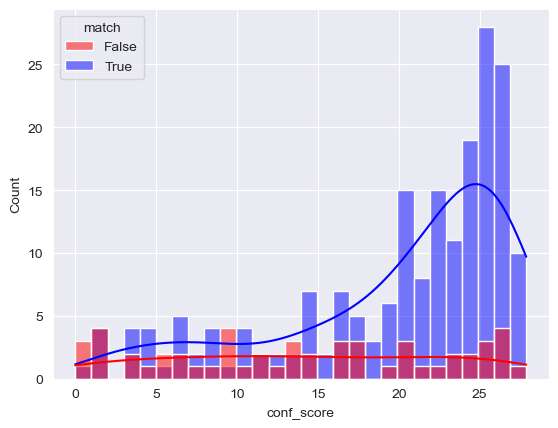

In [15]:
sns.set_style('darkgrid')
palette = {True: 'blue', False: 'red'}
sns.histplot(data=ensembled_df, x='conf_score', hue='match', alpha=0.5,binwidth=1, kde=True, palette=palette)
plt.savefig('total_distribution.png')

# Part 5: Confidence Classification

In [16]:
# separate high and low confidence values
# dependencies: os, pandas
def confidence_classification(data, output_dir, low_confidence=0.25, high_confidence=0.75, threshold=0.5, use_percentiles=True):
    """
    Classify data into high, medium, and low confidence based on either specific scores or percentiles.

    Parameters:
        data (DataFrame): The input data containing confidence scores in 'conf_score' column.
        low_confidence (float): The lower bound for low confidence, as a score or percentile.
        high_confidence (float): The threshold for high confidence, as a score or percentile.
        threshold (float): Score threshold to define 'high_conf_df' and 'low_conf_df'.
        output_dir (str): Directory to save output CSV files.
        use_percentiles (bool): If True, interpret low_confidence and high_confidence as percentiles.
    """
    # Convert percentiles to score thresholds if needed
    if use_percentiles:
        low_confidence = data['conf_score'].quantile(low_confidence)
        high_confidence = data['conf_score'].quantile(high_confidence)
        threshold = data['conf_score'].quantile(threshold)

    # Classify confidence levels
    confidence_labels = []
    for _, row in data.iterrows():
        if row['conf_score'] >= high_confidence:
            confidence_labels.append('high')
        elif row['conf_score'] <= low_confidence:
            confidence_labels.append('low')
        else:
            confidence_labels.append('medium')
    data['conf_label'] = confidence_labels

    # Separate high and low confidence data based on the threshold
    high_conf_df = data[data['conf_score'] >= threshold]
    low_conf_df = data[data['conf_score'] < threshold]

    # Save results to CSV
    os.makedirs(output_dir, exist_ok=True)
    high_conf_df.to_csv(os.path.join(output_dir, "high_conf_scores.csv"), index=False)
    low_conf_df.to_csv(os.path.join(output_dir, "low_conf_scores.csv"), index=False)

    print("High and low confidence data saved.")
    return high_conf_df, low_conf_df

In [17]:
# Function to select n examples of each label for few-shot prompting
def few_shot_data(data, labels, label_metric, threshold=0.75, n=1):
    """
    Args:
        data (DataFrame): DataFrame containing labeled examples along with their confidence scores.
        labels (list): List of possible labels (e.g., ["for", "against", "neutral"]).
        label_metric (str): Column name in the DataFrame corresponding to the label (e.g., "Stance").
        threshold (float): Quantile threshold for few shot examples, examples chosen below threshold
        n (int): Number of top examples to retrieve for each label, based on confidence score. Default is 1.

    Returns:
        tuple: 
            dict: A dictionary where each key is a label, and each value is a DataFrame of the top n examples 
                  for that label, selected by highest confidence score.
            DataFrame: A combined DataFrame of all selected few-shot examples.
    """
    
    few_shot_examples = {}
    combined_examples = []

    # Calculate the quantile threshold for collecting few shot examples
    conf_threshold = data['conf_score'].quantile(threshold)
    
    targets = data['Target'].unique()
    
    for target in targets:
        target_df = data[data['Target'] == target]
        few_shot_examples[target] = {}
        for label in labels:
            label_df = target_df[(target_df[label_metric] == label) & (target_df['conf_score'] <= conf_threshold)]
            top_n = label_df.nlargest(n, 'conf_score')
            
            # Add the top n examples to the few_shot_examples dictionary under the current target and label
            few_shot_examples[target][label] = top_n
            combined_examples.append(top_n)

    # Combination of all few-shot data
    combined_df = pd.concat(combined_examples)
    
    return few_shot_examples, combined_df

In [18]:
def remove_between(text, start_delim, end_delim):
    pattern = re.compile(f"{re.escape(start_delim)}.*?{re.escape(end_delim)}", re.DOTALL | re.IGNORECASE)
    return pattern.sub("", text)

In [19]:
def few_shot_by_target(few_shot_examples):
    """
    Generates a dictionary of few-shot prompting strings for each target from examples grouped by target and label.

    Args:
        few_shot_examples (dict): A nested dictionary where the top-level keys are targets,
                                  the second-level keys are labels, and the values are DataFrames
                                  of examples for those labels.

    Returns:
        dict: A dictionary where each key is a target, and the value is a string containing
              the formatted few-shot examples for that target.
    """
    few_shot_prompts = {}
    
    # Iterate over each target
    for target, label_dict in few_shot_examples.items():
        count = 1
        target_prompt = ""
        # Iterate over each label within the target
        for label, examples in label_dict.items():
            # Iterate over the examples for the current label
            for _, row in examples.iterrows():
                prompt = row['prompts']  # Extract the prompt text
                
                # Clean up the prompt if necessary
                prompt = remove_between(prompt, "\nWhich of the following", "'neutral'.")
                
                # Append the example to the target's prompt string
                target_prompt += f"Example {count}:\n{prompt}Label: {label}\n"
                count += 1  # Increment the example counter
        
        # Add the target's prompt string to the dictionary
        few_shot_prompts[target] = target_prompt
    
    return few_shot_prompts

In [20]:
high_conf_df, low_conf_df = confidence_classification(ensembled_df, os.getcwd())

High and low confidence data saved.


# Part 6: Low Confidence Reevaluation

In [21]:
few_shot_examples, combined_df = few_shot_data(ensembled_df, labels, label_metric)

In [22]:
few_shot_prompts = few_shot_by_target(few_shot_examples)

## Genetic Algorithm

Chromosome Representation:

- Instruction
- Focus
- Context
- Additive

Initial Population:

1. (Instruction) Provide a shortened reasoning, (Focus) focusing on key ideas, (Context) as to why each statement is given its corresponding label. (No Additive)
2. (Instruction) Give a description, (Focus) that centers around main points, (Context) for the label given to each statement. (Additive) Briefly state whether this label seems correct.

In [23]:
parents = {
    'Instruction': ['Provide a shortened reasoning', 'Give a description'],
    'Focus': ['focusing on key ideas', 'that centers around main points'],
    'Context': ['as to why each statement is given its corresponding label', 'for the label given to each statement'],
    'Additive': ['', 'Briefly state whether this label seems correct']
}

In [24]:
import random

# Generate initial population
def initialize_population(parents, pop_size=10):
    """
    Initializes a population for a genetic algorithm by randomly generating chromosomes
    based on the provided parent components.

    Args:
        parents (dict): A dictionary where each key represents a prompt component 
                        (e.g., 'Instruction', 'Focus') and its value is a list of 
                        possible options for that component.
        pop_size (int): The desired size of the population (number of chromosomes to generate). 
                        Default is 10.

    Returns:
        list: A list of dictionaries, where each dictionary represents a chromosome.
              Each chromosome is a combination of randomly selected components from 
              the `parents` dictionary.
    """
    population = []
    for _ in range(pop_size):
        while True: 
            # Randomly select one value for each key from the parents dictionary
            chromosome = {k: random.choice(v) for k, v in parents.items()}
            # Check for duplicates
            if chromosome not in population:
                population.append(chromosome)
                break

    return population

In [25]:
def evaluate_fitness(chromosome, few_shot_prompts, test_data, dataset_name, model_name, verbose=False):
    """
    Evaluates the fitness of a chromosome by calculating the mean confidence score
    of predictions on the test dataset.

    Args:
        chromosome (dict): A dictionary with prompt components.
        few_shot_prompts (dict): Labeled few-shot prompts for re-labeling purposes.
        test_data (pd.DataFrame): The dataset to label.
        dataset_name (str): The name of the dataset.
        model_name (str): The model used for labeling.
        verbose (bool): Whether to print detailed logs.

    Returns:
        float: The mean confidence score as the fitness metric.
    """
    
    # generate prompt from chromosome components
    # use loop to combine prompt because positions may be switched
    # forgo use of punctuation to minimize prompt abnormalities/confusion 
    prompt = ''
    for val in chromosome.values():
        prompt += val.lower() + ' '
        
    if verbose:
        print(f"Generating prompt: {prompt}")
    
    adjusted_prompts = prompt_adjuster(few_shot_prompts, model_name, genetic=prompt)

    # label test dataset
    test_df = test_data.copy()
    label_dataset(dataset_name=dataset_name, model_name=model_name, output_dir="./chain_out", sample_size=-1, CoT=False,
             data=test_data, prompt_mod=adjusted_prompts)
    
    genetic_link = pd.read_pickle("./chain_out/results_df.pkl")
    links = [genetic_link]
    names = ["genetic"]

    test_chained_df, test_chained_meta_data = chain_dataframes(links, "Stance")
    test_ensembled_df = backward_pass(test_chained_df, len(links))

    fitness_score = test_ensembled_df['conf_score'].mean()
    if verbose:
        print(f"Generating fitness-score: {fitness_score}\n")
    
    return fitness_score

In [26]:
def select_population(population, fitness_scores, n_parents=5):
    """
    Selects the n top-performing individuals from the population based on fitness scores.
    These individuals will be parents of later generations.

    Args:
        population (list): A list of chromosomes, where each chromosome is a dictionary of components.
        fitness_scores (list): A list of fitness scores corresponding to each chromosome in the population.
        n_parents (int): The number of top individuals to select. Default is 5.

    Returns:
        tuple: A tuple containing:
            - A list of the top n individuals based on their fitness scores.
            - A list of their corresponding fitness scores.
    """
    
    sorted_population_scores = sorted(zip(fitness_scores, population), reverse=True)
    sorted_scores, sorted_population = zip(*sorted_population_scores)
    return list(sorted_population[:n_parents]), list(sorted_scores[:n_parents])

In [27]:
def crossover(parents, fitness_scores):
    """
    Performs crossover between selected parents to produce offspring.
    The function uses roulette wheel selection to choose the second parent 
    based on fitness scores, then combines their traits randomly to create 
    offspring.

    Args:
        parents (list): A list of dictionaries representing the selected parents, 
                         where each dictionary is a chromosome with prompt components.
        fitness_scores (list): A list of fitness scores corresponding to each parent. 
                               These scores are used for selecting parent pairs via 
                               roulette wheel selection.

    Returns:
        list: A list of offspring, where each offspring is a dictionary representing 
              a new chromosome, created by combining the traits of two parent chromosomes.
    """
    
    offspring = []
    # each individual from selected population is a parent at least once 
    # roulette wheel selection for parent 2
    for i in range(len(parents)):
        parent_1 = parents[i]

        # exclude current parent
        temp_parents = parents[:i] + parents[i+1:]
        scores = sorted(fitness_scores, reverse=True)
        # exclude current score
        del scores[i]
        
        choice = random.uniform(0, sum(scores))
        j = 0
        roulette_sum = scores[j]
        
        while roulette_sum < choice and j < len(scores) - 1:
            j += 1
            roulette_sum += scores[j]

        parent_2 = temp_parents[j]

        # crossover
        child = {key: random.choice([parent_1[key], parent_2[key]]) for key in parents[0].keys()}
        offspring.append(child)
    
    return offspring    

In [28]:
def mutation(chromosome, model_name, swap_mutation_rate=0.25, semantic_mutation_rate=0.5):
    """
    Applies mutation to a given chromosome. The mutation process includes two possible 
    types of mutations: swapping positions of keys in the chromosome and modifying 
    the value of a single key using semantic mutation.

    Args:
        chromosome (dict): A dictionary representing the chromosome (a set of prompt components) to be mutated.
        model_name (str): The name of the model used for semantic mutation (e.g., "gpt-4o", "gpt-4o-mini").
        swap_mutation_rate (float): The probability of swapping the positions of two keys in the chromosome. 
                                     Default is 0.25.
        semantic_mutation_rate (float): The probability of modifying the value of a key in the chromosome using 
                                        semantic mutation. Default is 0.5.

    Returns:
        dict: The mutated chromosome, with either keys swapped or values modified based on the mutation rates.
    """
    
    mutate = random.random()
    # swap positions of keys
    if mutate <= swap_mutation_rate:
        keys = list(chromosome.keys())
        i, j = random.sample(keys, 2)
        chromosome[i], chromosome[j] = chromosome[j], chromosome[i]
    # edit value of single key
    if mutate <= semantic_mutation_rate:
        chromosome = semantic_mutation(chromosome, model_name)

    return chromosome

In [29]:
def semantic_mutation(chromosome, model_name):
    """
    Performs a semantic mutation on a given chromosome by modifying the value of one key 
    to be semantically similar to its original value using a language model.

    Args:
        chromosome (dict): A dictionary representing the chromosome, where the values are prompt components 
                           that may be semantically modified.
        model_name (str): The name of the model used for generating the semantically modified text. 
                          Examples include "gpt-4o" or "gpt-4o-mini".

    Returns:
        dict: The updated chromosome with the value of one key modified semantically.
    """
    
    prompt = 'Without additional explanation, modification or punctuation, modify 1 or 2 words in the segment so that it is semantically similar:\n'

    non_empty_items = [(k, v) for k, v in chromosome.items() if v != ""]
    key, value = random.choice(non_empty_items)
    prompt += value

    if model_name in ["gpt-4o", "gpt-4o-mini"]:
        openai_token = os.getenv("OPENAI_API_KEY")
        client = OpenAI(api_key=openai_token)
        is_openai = True
    else:
        model_path = MODELS[model_name]
        hf_token = os.getenv("HF_TOKEN")
        client = pipeline("text-generation", model=model_path, use_auth_token=hf_token)
        is_openai = False

    if is_openai:
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt},
            ]
        )
        new_value = response.choices[0].message.content
    else:
        response = client(f"Target: {target}\n{full_prompt}", max_length=1024)
        new_value = response[0]["generated_text"]

    new_value = new_value.strip('"')
    chromosome[key] = new_value
    return chromosome

In [30]:
def genetic_algorithm(parents, data, model_name, few_shot_prompts, dataset_name, 
                      pop_size=10, generations=10, swap_mutation_rate=0.25, semantic_mutation_rate=0.5,
                      n_parents=5, verbose=False):
    """
    Executes a genetic algorithm to optimize a population of chromosomes over a number of generations.

    Parameters:
    - parents (list): Initial set of parent chromosomes to seed the population.
    - data (any): Dataset used for evaluating the fitness of the chromosomes.
    - model_name (str): The name of the model used in fitness evaluation. Must be a valid model listed in MODELS.
    - few_shot_prompts (list): Prompts used in the evaluation process for few-shot learning scenarios.
    - dataset_name (str): Name of the dataset used for context in evaluation.
    - pop_size (int, optional): The size of the population for each generation. Default is 10.
    - generations (int, optional): Number of generations to run the genetic algorithm. Default is 10.
    - swap_mutation_rate (float, optional): Probability of performing a swap mutation on an offspring. Default is 0.25.
    - semantic_mutation_rate (float, optional): Probability of performing a semantic mutation on an offspring. Default is 0.5.
    - n_parents (int, optional): Number of top-performing parents to select for producing the next generation. Default is 5.
    - verbose (bool, optional): If True, outputs detailed information during execution. Default is False.

    Returns:
    - tuple: A tuple containing:
        - population (list): The final population after all generations.
        - gen_max_score (list): A list of maximum fitness scores for each generation.
        - gen_min_score (list): A list of minimum fitness scores for each generation.
        - gen_max_chromosome (list): A list of chromosomes with the maximum fitness for each generation.
        - gen_min_chromosome (list): A list of chromosomes with the minimum fitness for each generation.

    Raises:
    - ValueError: If an invalid `model_name` is provided.

    Description:
    The `genetic_algorithm` function simulates a genetic algorithm, optimizing a population of chromosomes over multiple generations. 
    Each generation involves evaluating the fitness of the population, selecting the top-performing parents, generating offspring through 
    crossover, and applying mutations to introduce variability. The algorithm tracks the maximum and minimum fitness scores along with 
    their associated chromosomes for each generation.

    The process involves:
    1. Initializing a population using the provided parents.
    2. Iteratively evolving the population through selection, crossover, and mutation.
    3. Evaluating the fitness of new offspring in each generation.
    4. Storing and returning the final population and fitness statistics.
    """

    if model_name not in MODELS:
        raise ValueError("Invalid model selection! Choose from supported models.")

    # track max/min scores and associated chromosome
    gen_max_score = []
    gen_min_score = []
    gen_max_chromosome = []
    gen_min_chromosome = []

    # generate starting population
    population = initialize_population(parents, pop_size)
    # track evaluated chromosomes to reduce redundancy
    evaluated_chromosomes = {}
    
    for gen in range(generations):
        print(f'Generation: {gen + 1}')

        if gen == 0:
            # Evaluate initial population fitness
            fitness_scores = []
            for chromosome in population:
                score = evaluate_fitness(chromosome, few_shot_prompts, data, dataset_name, model_name, verbose)
                chromosome_tuple = tuple(chromosome.items())
                evaluated_chromosomes[chromosome_tuple] = score
                fitness_scores.append(evaluated_chromosomes[chromosome_tuple])
        else:
            new_offspring = population[-len(offspring):]
            for chromosome in new_offspring:
                chromosome_tuple = tuple(chromosome.items())
                if chromosome_tuple not in evaluated_chromosomes:
                    score = evaluate_fitness(chromosome, few_shot_prompts, data, dataset_name, model_name, verbose)
                    evaluated_chromosomes[chromosome_tuple] = score
                fitness_scores.append(evaluated_chromosomes[chromosome_tuple])
        """
        if gen == 0:
            # evaluate initial population fitness
            fitness_scores = [evaluate_fitness(chromosome, few_shot_prompts, data, dataset_name, model_name, verbose) for chromosome in population]
        else: 
            # evaluate fitness of new selected parents
            fitness_scores += [evaluate_fitness(chromosome, few_shot_prompts, data, dataset_name, model_name, verbose) for chromosome in population[-len(offspring):]]
        """
        # select new parents 
        parents, fitness_scores = select_population(population, fitness_scores, n_parents)
        # generate offspring from parents
        offspring = crossover(parents, fitness_scores)
        # mutate offspring
        offspring = [mutation(child, model_name, swap_mutation_rate=swap_mutation_rate, semantic_mutation_rate=semantic_mutation_rate) for child in offspring]

        # append max/min score and chromosome
        gen_max_score.append(max(fitness_scores))
        gen_min_score.append(min(fitness_scores))
        gen_max_chromosome.append(parents[0])
        gen_min_chromosome.append(parents[-1])
        
        population = parents + offspring

    return population, gen_max_score, gen_min_score, gen_max_chromosome, gen_min_chromosome

## Prompt Adjustment

In [31]:
from openai import OpenAI
from transformers import pipeline

def prompt_adjuster(few_shot_prompts, model_name, genetic=None):
    """
    Adjusts prompts by interacting with the OpenAI API and updates each target's examples.

    Args:
        few_shot_prompts (dict): A dictionary where keys are targets, and values are strings of examples.
        model_name (str): The name of the model to be used for adjustment.

    Returns:
        dict: A dictionary where each target is updated with the adjusted prompts.
    """

    if model_name not in MODELS:
        raise ValueError("Invalid model selection! Choose from supported models.")

    if model_name in ["gpt-4o", "gpt-4o-mini"]:
        openai_token = os.getenv("OPENAI_API_KEY")
        client = OpenAI(api_key=openai_token)
        is_openai = True
    else:
        model_path = MODELS[model_name]
        hf_token = os.getenv("HF_TOKEN")
        client = pipeline("text-generation", model=model_path, use_auth_token=hf_token)
        is_openai = False
    
    if genetic:
        adjuster = genetic
    else:
        adjuster = """
Provide a shortened reasoning, focusing on key ideas, as to why each statement is given its corresponding label.
"""
    
    instruction = adjuster + """

Format for each example:
Example: ...
Statement: ...
Label: ...
Reasoning: ...

Statements:

"""
    
    for target, prompt in few_shot_prompts.items():
        full_prompt = instruction + prompt

        if is_openai:
            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": "You are a helpful assistant."},
                    {"role": "user", "content": f"Target: {target}\n{full_prompt}"},
                ]
            )
            adjusted_prompt = response.choices[0].message.content
        else:
            response = client(f"Target: {target}\n{full_prompt}", max_length=1024)
            adjusted_prompt = response[0]["generated_text"]
            
        few_shot_prompts[target] = adjusted_prompt
    
    return few_shot_prompts

## Implementation

In [32]:
fin_pop, max_scores, min_scores, max_chroms, min_chroms = genetic_algorithm(parents=parents,
                                                                            data=combined_df, 
                                                                            model_name="gpt-4o-mini",
                                                                            few_shot_prompts=few_shot_prompts,
                                                                            dataset_name="SemEval2016",
                                                                            pop_size=4, 
                                                                            generations=3,
                                                                            swap_mutation_rate=0.5,
                                                                            semantic_mutation_rate=0.65,
                                                                            n_parents=2,
                                                                            verbose=True)

Generation: 1
Generating prompt: provide a shortened reasoning focusing on key ideas as to why each statement is given its corresponding label  


100%|██████████| 15/15 [00:05<00:00,  2.61it/s]


Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.
Generating fitness-score: 22.766666779800644

Generating prompt: provide a shortened reasoning that centers around main points as to why each statement is given its corresponding label  


100%|██████████| 15/15 [00:07<00:00,  2.05it/s]


Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.
Generating fitness-score: 24.074999916334857

Generating prompt: give a description that centers around main points as to why each statement is given its corresponding label  


...

Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.
Generating fitness-score: 24.341666765483506

Generation: 3
Generating prompt:  that centers around main points as to why each statement is given its corresponding label  


100%|██████████| 15/15 [00:08<00:00,  1.85it/s]


Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.
Generating fitness-score: 24.66666651412122

Generating prompt:  as to why each statement is given its corresponding label that focuses on main points provide a description 


100%|██████████| 15/15 [00:07<00:00,  1.89it/s]


Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.
Generating fitness-score: 24.408333181099042



In [33]:
print(max_scores)
print(min_scores)
print()
print(max_chroms)
print()
print(min_chroms)

[24.599999918826562, 24.599999918826562, 24.66666651412122]
[24.258333313814045, 24.399999908606162, 24.599999918826562]

[{'Instruction': 'Give a description', 'Focus': 'that centers around main points', 'Context': 'as to why each statement is given its corresponding label', 'Additive': ''}, {'Instruction': 'Give a description', 'Focus': 'that centers around main points', 'Context': 'as to why each statement is given its corresponding label', 'Additive': ''}, {'Instruction': '', 'Focus': 'that centers around main points', 'Context': 'as to why each statement is given its corresponding label', 'Additive': ''}]

[{'Instruction': 'Give a description', 'Focus': 'focusing on key ideas', 'Context': 'for the label given to each statement', 'Additive': 'Briefly state whether this label seems correct'}, {'Instruction': '', 'Focus': 'that centers around main points', 'Context': 'as to why each statement is given its corresponding label', 'Additive': 'Provide a description'}, {'Instruction': 'Gi

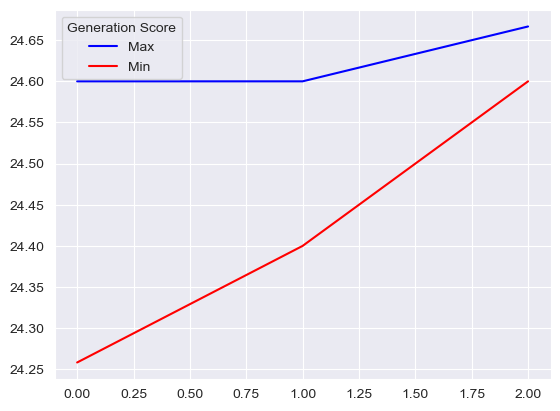

In [34]:
plt.plot(range(len(max_scores)), max_scores, color='blue', label='Max')
plt.plot(range(len(min_scores)), min_scores, color='red', label='Min')
plt.legend(title='Generation Score')
plt.show()

In [35]:
final_chrom = max_chroms[-1]
final_prompt = ""
for val in final_chrom.values():
    if val != "":
        final_prompt += val + " "

print(f'Final Genetic Prompt:\n{final_prompt}')

Final Genetic Prompt:
that centers around main points as to why each statement is given its corresponding label 


In [36]:
adjusted_prompts = prompt_adjuster(few_shot_prompts, "gpt-4o-mini")

In [37]:
adjusted_prompts_genetic = prompt_adjuster(few_shot_prompts, "gpt-4o-mini", genetic=final_prompt)

# Part 7: Re-Labeling

In [38]:
reeval_df = low_conf_df.copy()

## Standard Re-Labeling

In [39]:
# re-evaluation with standard prompt adjustment
label_dataset(dataset_name="SemEval2016", model_name="gpt-4o-mini", output_dir="./chain_out", sample_size=-1, CoT=False,
             data=reeval_df, prompt_mod=adjusted_prompts)

100%|██████████| 125/125 [01:05<00:00,  1.90it/s]

Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.


In [40]:
# path specifically for this test
re_gpt_link = pd.read_pickle("./chain_out/results_df.pkl")

links = [re_gpt_link]
names = ["gpt"]

In [41]:
re_chained_df, re_chained_meta_data = chain_dataframes(links, "Stance")
re_ensembled_df = backward_pass(re_chained_df, len(links))

In [42]:
re_ensembled_df['match'] = re_ensembled_df['Stance'] == re_ensembled_df['link_0_label']

## Genetic Re-Labeling

In [43]:
# re-evaluation with genetic prompt adjustment
label_dataset(dataset_name="SemEval2016", model_name="gpt-4o-mini", output_dir="./chain_out", sample_size=-1, CoT=False,
             data=reeval_df, prompt_mod=adjusted_prompts_genetic)

100%|██████████| 125/125 [01:07<00:00,  1.86it/s]

Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.


In [44]:
re_gpt_link = pd.read_pickle("./chain_out/results_df.pkl")

links = [re_gpt_link]
names = ["gpt"]

In [45]:
re_chained_df_genetic, re_chained_meta_data_genetic = chain_dataframes(links, "Stance")
re_ensembled_df_genetic = backward_pass(re_chained_df_genetic, len(links))

In [46]:
re_ensembled_df_genetic['match'] = re_ensembled_df_genetic['Stance'] == re_ensembled_df_genetic['link_0_label']

# Results

## Synthetic Few-Shot

In [47]:
re_chained_meta_data

{'link_0_full_acc': 0.752,
 'link_0_full_f1': 0.751706447545759,
 'link_0_threshold': 0.0,
 'link_0_retained_acc': 0.752,
 'link_0_retained_f1': 0.751706447545759,
 'link_0_retained_size': 125,
 'total_acc': 0.752,
 'total_f1': 0.751706447545759}

In [48]:
percentage_true = (re_ensembled_df['match'].sum() / len(re_ensembled_df)) * 100
print(f"Re-Labeled Accuracy: {percentage_true}%")

Re-Labeled Accuracy: 75.2%


In [49]:
labels = re_ensembled_df['Stance'].unique()

for label in labels:
    lab_acc_df = re_ensembled_df[re_ensembled_df['Stance'] == label]
    lab_acc = round(accuracy_score(lab_acc_df['pred_label'], lab_acc_df['Stance']), 3)
    print(f'{label} accuracy:', lab_acc)

against accuracy: 0.8
neutral accuracy: 0.718
for accuracy: 0.722


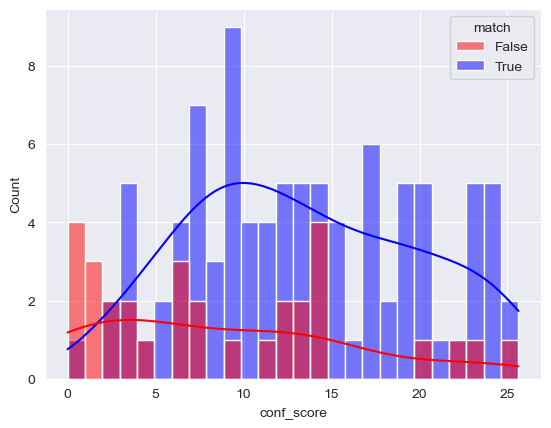

In [50]:
palette = {True: 'blue', False: 'red'}
sns.histplot(data=re_ensembled_df, x='conf_score', hue='match', alpha=0.5,binwidth=1, kde=True, palette=palette)
plt.savefig('re_labeled_low_conf_distribution.png')

## Genetic Algorithm + Synthetic Few-Shot

In [51]:
re_chained_meta_data_genetic

{'link_0_full_acc': 0.768,
 'link_0_full_f1': 0.7673622180360334,
 'link_0_threshold': 0.25,
 'link_0_retained_acc': 0.768,
 'link_0_retained_f1': 0.7673622180360334,
 'link_0_retained_size': 125,
 'total_acc': 0.768,
 'total_f1': 0.7673622180360334}

In [52]:
percentage_true = (re_ensembled_df_genetic['match'].sum() / len(re_ensembled_df_genetic)) * 100
print(f"Re-Labeled Accuracy: {percentage_true}%")

Re-Labeled Accuracy: 76.8%


In [53]:
labels = re_ensembled_df_genetic['Stance'].unique()

for label in labels:
    lab_acc_df = re_ensembled_df_genetic[re_ensembled_df['Stance'] == label]
    lab_acc = round(accuracy_score(lab_acc_df['pred_label'], lab_acc_df['Stance']), 3)
    print(f'{label} accuracy:', lab_acc)

against accuracy: 0.82
neutral accuracy: 0.718
for accuracy: 0.75


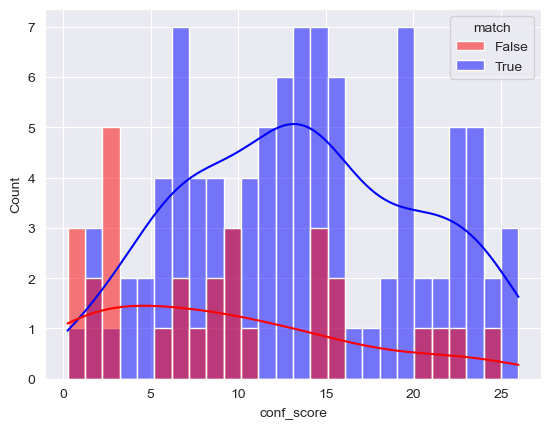

In [54]:
palette = {True: 'blue', False: 'red'}
sns.histplot(data=re_ensembled_df_genetic, x='conf_score', hue='match', alpha=0.5,binwidth=1, kde=True, palette=palette)
plt.savefig('re_labeled_low_conf_distribution_genetic.png')

## Initial

In [55]:
percentage_true = (low_conf_df['match'].sum() / len(low_conf_df)) * 100
print(f"Initial Labeled Accuracy: {percentage_true}%")

Initial Labeled Accuracy: 68.8%


In [56]:
labels = low_conf_df['Stance'].unique()

for label in labels:
    lab_acc_df = low_conf_df[low_conf_df['Stance'] == label]
    lab_acc = round(accuracy_score(lab_acc_df['pred_label'], lab_acc_df['Stance']), 3)
    print(f'{label} accuracy:', lab_acc)

against accuracy: 0.7
neutral accuracy: 0.615
for accuracy: 0.75


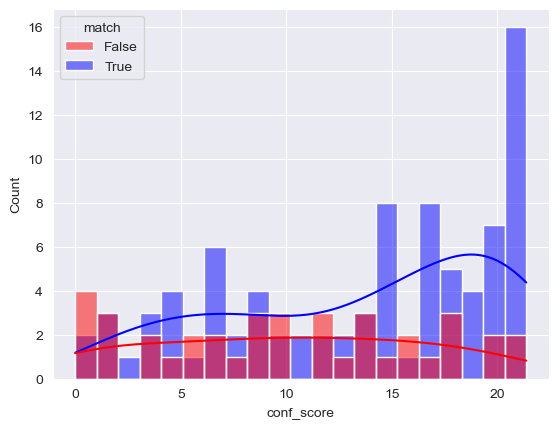

In [57]:
sns.histplot(data=low_conf_df, x='conf_score', hue='match', alpha=0.5, binwidth=1, kde=True, palette=palette)
plt.savefig('low_conf_distribution.png')